In [1]:
pip install qiskit qiskit-machine-learning qiskit-aer

In [2]:
pip install estimator


In [3]:
!pip install --upgrade qiskit-machine-learning

In [4]:
pip install qiskit qiskit-machine-learning qiskit-aer

In [5]:
!pip install pylatexenc

1. Generating Circuit Diagram...


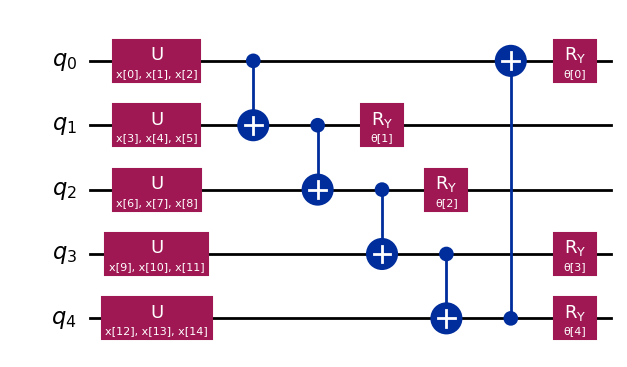

2. Training Classical Model...


3. Extracting Quantum Features...
4. Training Hybrid Model...
5. Generating Final Plots...


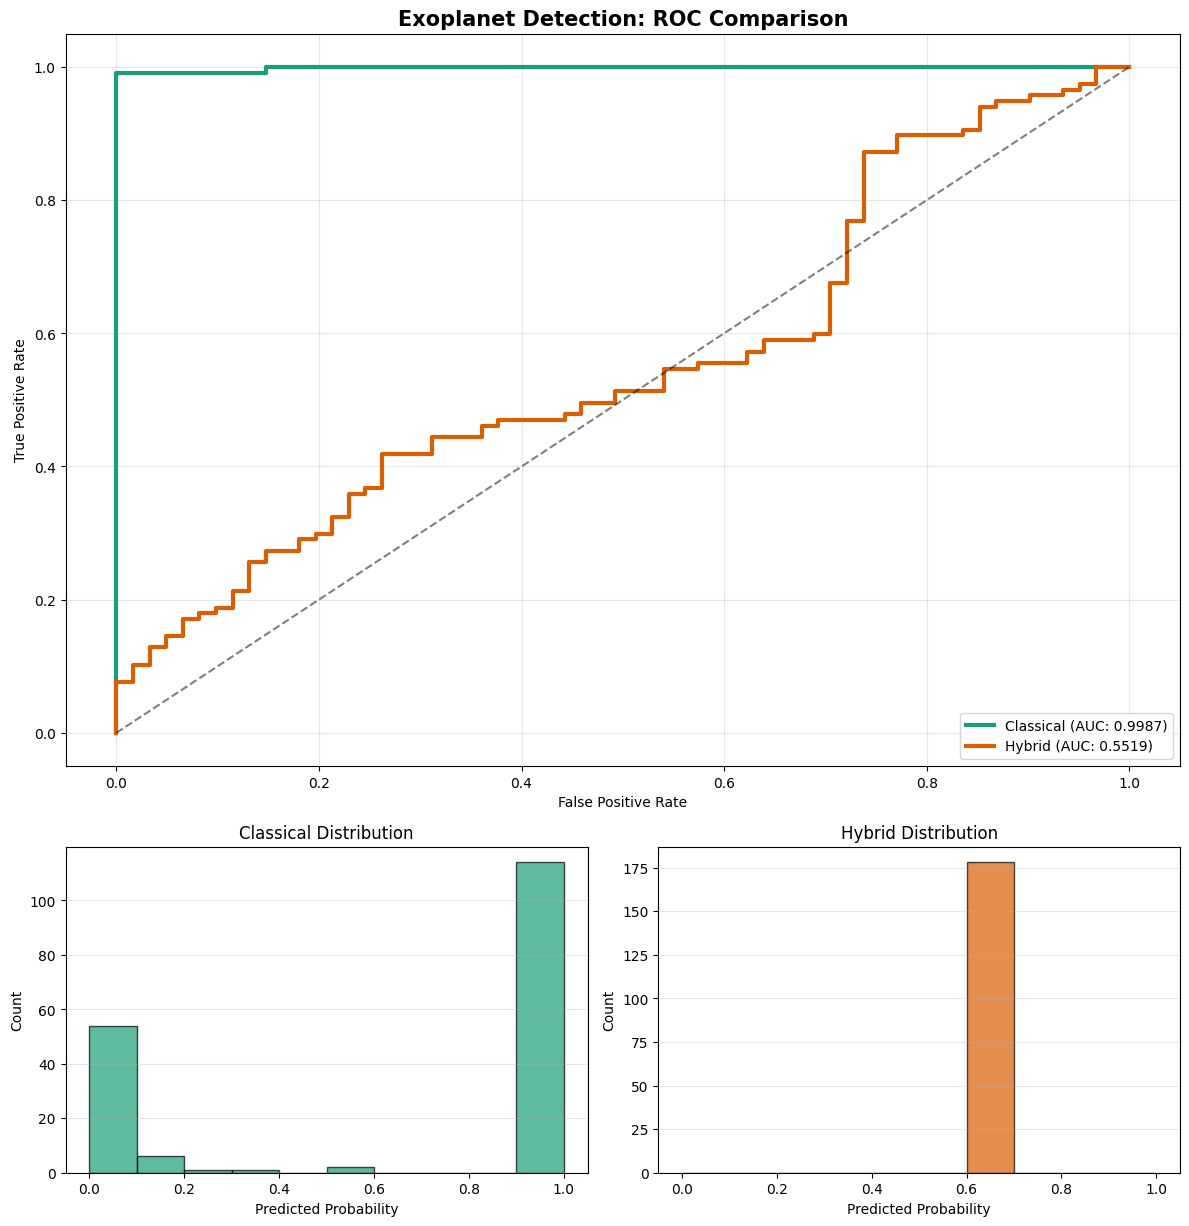

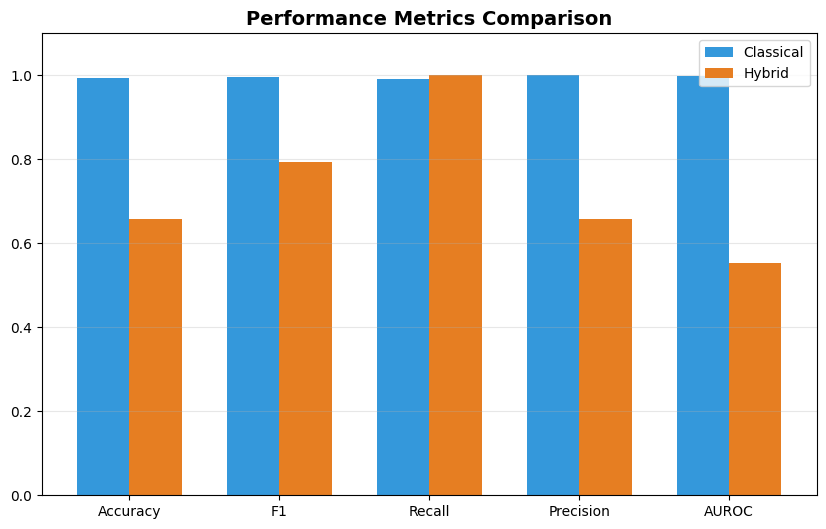


Final Comparison Table
           Classical    Hybrid
Accuracy    0.994382  0.657303
F1          0.995708  0.793220
Recall      0.991453  1.000000
Precision   1.000000  0.657303
AUROC       0.998739  0.551913


In [17]:
from pathlib import Path
# -*- coding: utf-8 -*-
# %matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import torch.nn as nn
import torch.optim as optim

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, roc_curve
)

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from qiskit.visualization import circuit_drawer
from qiskit_machine_learning.neural_networks import EstimatorQNN


path= "/content/Copy train_data - train_data.csv.csv"
features= [
    'koi_score', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec',
    'koi_teq', 'koi_impact', 'koi_tce_plnt_num', 'koi_depth',
    'koi_steff', 'koi_prad', 'koi_fpflag_nt', 'koi_model_snr',
    'koi_slogg', 'koi_insol', 'koi_kepmag'
]

# ── Cell 2: Data Logic ─────────────────────────────────────────────────────
def load_data(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f" CSV not found at {path}. Please upload it to Colab.")
    df = pd.read_csv(path)
    available = [f for f in features if f in df.columns]
    if 'target' not in df.columns and 'koi_disposition' in df.columns:
        df['target'] = df['koi_disposition'].apply(lambda x: 1 if x == 'CONFIRMED' else 0)
    df = df[available + ['target']].dropna()
    return df[available].values, df['target'].values.astype(int), available

def preprocess(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    angle_scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
    return angle_scaler.fit_transform(X_scaled)


def create_u_gate_circuit(num_input_features=15, num_qubits=5):
    f_per_q = 3
    actual_in = min(num_input_features, num_qubits * f_per_q)
    x, theta = ParameterVector('x', actual_in), ParameterVector('θ', num_qubits)
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        idx = i * f_per_q
        qc.u(x[idx % actual_in], x[(idx+1) % actual_in], x[(idx+2) % actual_in], i)
    for i in range(num_qubits - 1): qc.cx(i, i + 1)
    qc.cx(num_qubits - 1, 0)
    for i in range(num_qubits): qc.ry(theta[i], i)
    return qc, x, theta


class CNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveMaxPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(32, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1), nn.Sigmoid()
        )
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x).view(x.size(0), -1)
        return self.fc(x)

# Training & Evaluation
def train_and_evaluate(X, y, label="Model", epochs=30):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    X_tr, y_tr = torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    model = CNN(X.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=0.002)
    criterion = nn.BCELoss()

    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_tr), y_tr)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        probs = model(torch.tensor(X_test, dtype=torch.float32)).numpy().flatten()
        preds = (probs > 0.5).astype(int)

    results = {
        'Accuracy': accuracy_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'AUROC': roc_auc_score(y_test, probs)
    }
    fpr, tpr, _ = roc_curve(y_test, probs)
    return results, fpr, tpr, probs

# Visualizations
def plot_comprehensive_eval(classical_eval, hybrid_eval):

    res_c, fpr_c, tpr_c, probs_c = classical_eval
    res_h, fpr_h, tpr_h, probs_h = hybrid_eval

    fig = plt.figure(figsize=(12, 16))
    gs = GridSpec(4, 2)
    colors = plt.get_cmap("Dark2")

    ax_roc = fig.add_subplot(gs[:2, :2])
    ax_roc.plot(fpr_c, tpr_c, color=colors(0), lw=3, label=f'Classical (AUC: {res_c["AUROC"]:.4f})')
    ax_roc.plot(fpr_h, tpr_h, color=colors(1), lw=3, label=f'Hybrid (AUC: {res_h["AUROC"]:.4f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax_roc.set_title("Exoplanet Detection: ROC Comparison", fontsize=15, fontweight='bold')
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.legend(loc="lower right")
    ax_roc.grid(True, alpha=0.3)

    #Probability Histograms
    grid_positions = [(2, 0), (2, 1), (3, 0), (3, 1)]
    titles = ["Classical Distribution", "Hybrid Distribution"]
    all_probs = [probs_c, probs_h]

    for i in range(2):
        row, col = grid_positions[i]
        ax = fig.add_subplot(gs[row, col])
        ax.hist(all_probs[i], range=(0, 1), bins=10, color=colors(i), edgecolor='black', alpha=0.7)
        ax.set(title=titles[i], xlabel="Predicted Probability", ylabel="Count")
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_metrics_bar(res_c, res_h):
    metrics = ['Accuracy', 'F1', 'Recall', 'Precision', 'AUROC']
    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, [res_c[m] for m in metrics], width, label='Classical', color='#3498db')
    ax.bar(x + width/2, [res_h[m] for m in metrics], width, label='Hybrid', color='#e67e22')

    ax.set_title("Performance Metrics Comparison", fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.1)
    ax.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

#Main
def main():
    try:
        # Load and Preprocess
        X, y, feats = load_data(path)
        X_angles = preprocess(X)

        # 1. Output: Circuit
        print("1. Generating Circuit Diagram...")
        qc, x_v, th_v = create_u_gate_circuit(len(feats), 5)
        display(qc.draw(output='mpl', style='iqp'))

        # 2. Evaluation: Classical
        print("2. Training Classical Model...")
        res_c, fpr_c, tpr_c, probs_c = train_and_evaluate(X_angles, y, "Classical")

        # 3. Evaluation: Hybrid
        print("3. Extracting Quantum Features...")
        qnn = EstimatorQNN(
            circuit=qc,
            observables=[SparsePauliOp("I"*i + "Z" + "I"*(4-i)) for i in range(5)],
            input_params=list(x_v), weight_params=list(th_v)
        )
        X_q = qnn.forward(X_angles, np.random.rand(qnn.num_weights))
        print("4. Training Hybrid Model...")
        res_h, fpr_h, tpr_h, probs_h = train_and_evaluate(X_q, y, "Hybrid")

        # 4. Outputs: Final Graphs
        print("5. Generating Final Plots...")
        plot_comprehensive_eval((res_c, fpr_c, tpr_c, probs_c), (res_h, fpr_h, tpr_h, probs_h))
        plot_metrics_bar(res_c, res_h)

        # 5. Results Table
        print("\n" + "="*40 + "\nFinal Comparison Table\n" + "="*40)
        print(pd.DataFrame([res_c, res_h], index=["Classical", "Hybrid"]).T)

    except Exception as e:
        print(f"ERROR: {e}")

if __name__ == "__main__":
    main()